In [ ]:
!mkdir flood_demo
!mkdir flood_demo/templates

In [ ]:
!ls flood_demo

templates


In [ ]:
html_code = """
<!DOCTYPE html>
<html>
<body>
<h2>Flood Detection Upload Page</h2>
<p>This page simulates phone camera input.</p>
</body>
</html>
"""

with open("flood_demo/templates/camera.html","w") as f:
    f.write(html_code)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Flood-Video.mp4 to Flood-Video.mp4


In [ ]:
!pip install opencv-python torch torchvision

In [ ]:
from google.colab.patches import cv2_imshow
import cv2
import random

video_path = list(uploaded.keys())[0]

cap = cv2.VideoCapture(video_path)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Demo flood prediction
    prob = random.random()

    if prob > 0.7:
        text = "🚨 FLOOD ALERT"
        color = (0,0,255)
    else:
        text = "SAFE"
        color = (0,255,0)

    cv2.putText(frame,
                f"{text} {prob:.2f}",
                (50,50),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                color,
                3)

    cv2.imshow("Flood Dashboard", frame)

    if cv2.waitKey(25) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

DisabledFunctionError: cv2.imshow() is disabled in Colab, because it causes Jupyter sessions
to crash; see https://github.com/jupyter/notebook/issues/3935.
As a substitution, consider using
  from google.colab.patches import cv2_imshow


In [ ]:
from google.colab.patches import cv2_imshow
import cv2
import random
import time

# load uploaded video
video_path = list(uploaded.keys())[0]

cap = cv2.VideoCapture(video_path)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # simulate flood prediction
    prob = random.random()

    if prob > 0.7:
        text = "🚨 FLOOD ALERT"
        color = (0,0,255)
    else:
        text = "SAFE"
        color = (0,255,0)

    cv2.putText(frame,
                f"{text} {prob:.2f}",
                (40,60),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                color,
                3)

    # ✅ COLAB DISPLAY (NOT imshow)
    cv2_imshow(frame)

    time.sleep(0.03)

cap.release()

NameError: name 'uploaded' is not defined

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Flood-Video.mp4 to Flood-Video.mp4


In [ ]:
video_path = list(uploaded.keys())[0]

In [ ]:
from google.colab.patches import cv2_imshow
from IPython.display import clear_output
import cv2
import random
import time

In [ ]:
video_path = list(uploaded.keys())[0]

print("Video Loaded:", video_path)

cap = cv2.VideoCapture(video_path)

Video Loaded: Flood-Video.mp4


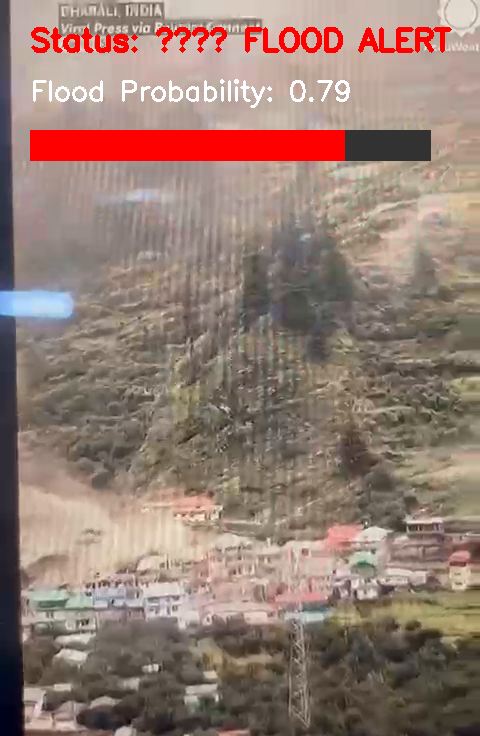

KeyboardInterrupt: 

In [ ]:
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # ---------- Simulated Flood Prediction ----------
    prob = random.random()   # replace later with your CNN model

    if prob > 0.7:
        status = "🚨 FLOOD ALERT"
        color = (0, 0, 255)
    else:
        status = "SAFE"
        color = (0, 255, 0)

    # ---------- Dashboard Text ----------
    cv2.putText(frame,
                f"Status: {status}",
                (30, 50),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                color,
                3)

    cv2.putText(frame,
                f"Flood Probability: {prob:.2f}",
                (30, 100),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.9,
                (255,255,255),
                2)

    # ---------- Risk Bar ----------
    bar_length = int(prob * 400)

    cv2.rectangle(frame, (30,130), (430,160), (50,50,50), -1)
    cv2.rectangle(frame, (30,130), (30+bar_length,160), color, -1)

    # ---------- Display (Colab Compatible) ----------
    clear_output(wait=True)
    cv2_imshow(frame)

    time.sleep(0.03)

cap.release()

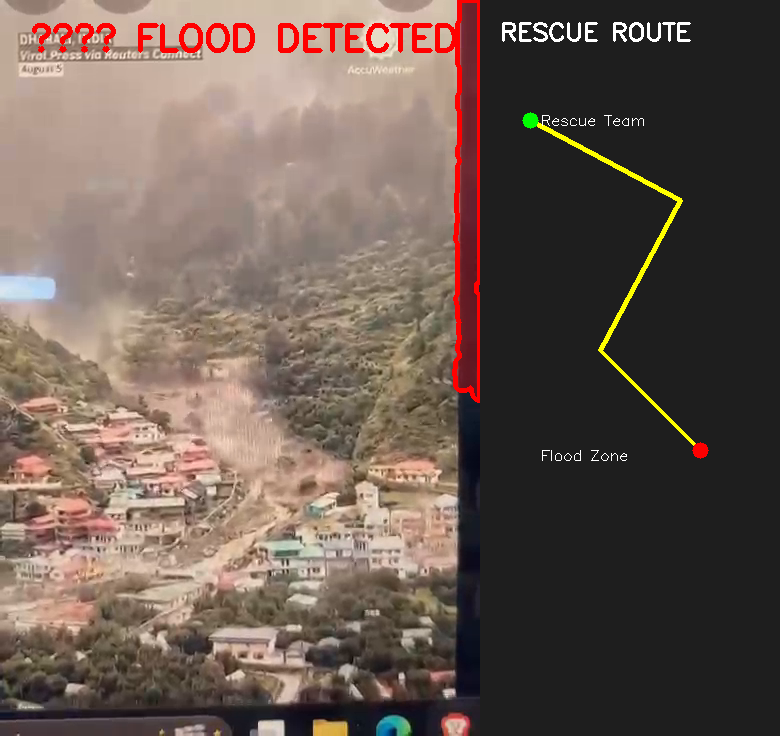

KeyboardInterrupt: 

In [ ]:
from google.colab.patches import cv2_imshow
from IPython.display import clear_output
import cv2
import numpy as np
import time

video_path = list(uploaded.keys())[0]
cap = cv2.VideoCapture(video_path)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    display = frame.copy()

    # -----------------------------
    # FLOOD REGION DETECTION
    # -----------------------------
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # water-like color range
    lower_blue = np.array([90,50,50])
    upper_blue = np.array([140,255,255])

    mask = cv2.inRange(hsv, lower_blue, upper_blue)

    # smooth mask
    mask = cv2.GaussianBlur(mask,(11,11),0)

    # find flood boundaries
    contours, _ = cv2.findContours(mask,
                                   cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    flood_detected = False

    for cnt in contours:
        area = cv2.contourArea(cnt)

        if area > 5000:   # ignore small noise
            flood_detected = True

            # draw boundary lines (map style)
            cv2.drawContours(display,[cnt],-1,(0,0,255),3)

            # transparent flood overlay
            overlay = display.copy()
            cv2.drawContours(overlay,[cnt],-1,(0,0,255),-1)
            display = cv2.addWeighted(overlay,0.3,display,0.7,0)

    # -----------------------------
    # ALERT TEXT
    # -----------------------------
    if flood_detected:
        cv2.putText(display,
                    "🚨 FLOOD DETECTED",
                    (30,50),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1.2,
                    (0,0,255),
                    4)

    else:
        cv2.putText(display,
                    "AREA SAFE",
                    (30,50),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1.2,
                    (0,255,0),
                    3)

    # -----------------------------
    # RESCUE ROUTE PANEL (RIGHT SIDE)
    # -----------------------------
    h, w, _ = display.shape

    panel = np.zeros((h,300,3), dtype=np.uint8)
    panel[:] = (30,30,30)

    cv2.putText(panel,"RESCUE ROUTE",(20,40),
                cv2.FONT_HERSHEY_SIMPLEX,0.8,(255,255,255),2)

    # simulated route
    pts = np.array([[50,120],[200,200],[120,350],[220,450]])
    cv2.polylines(panel,[pts],False,(0,255,255),3)

    cv2.circle(panel,(50,120),8,(0,255,0),-1)
    cv2.putText(panel,"Rescue Team",(60,125),
                cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,255,255),1)

    cv2.circle(panel,(220,450),8,(0,0,255),-1)
    cv2.putText(panel,"Flood Zone",(60,460),
                cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,255,255),1)

    # merge dashboard
    dashboard = np.hstack((display, panel))

    # -----------------------------
    # SHOW DASHBOARD
    # -----------------------------
    clear_output(wait=True)
    cv2_imshow(dashboard)

    time.sleep(0.05)

cap.release()

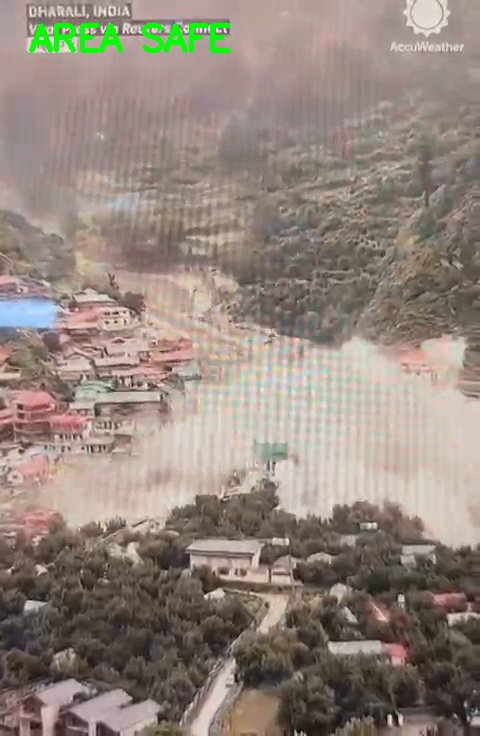

In [ ]:
from IPython.display import display, Image
import cv2
import numpy as np
import time

video_path = list(uploaded.keys())[0]
cap = cv2.VideoCapture(video_path)

display_handle = display(None, display_id=True)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    display_frame = frame.copy()
    h, w, _ = display_frame.shape

    # -----------------------------------
    # FLOOD REGION DETECTION
    # -----------------------------------
    hsv = cv2.cvtColor(display_frame, cv2.COLOR_BGR2HSV)

    lower_blue = np.array([90,50,50])
    upper_blue = np.array([140,255,255])

    mask = cv2.inRange(hsv, lower_blue, upper_blue)
    mask = cv2.GaussianBlur(mask,(11,11),0)

    contours,_ = cv2.findContours(mask,
                                  cv2.RETR_EXTERNAL,
                                  cv2.CHAIN_APPROX_SIMPLE)

    flood_detected = False
    flood_center = None

    for cnt in contours:
        if cv2.contourArea(cnt) > 5000:

            flood_detected = True

            # draw flood boundary
            cv2.drawContours(display_frame,[cnt],-1,(0,0,255),3)

            # compute flood center
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cx = int(M["m10"]/M["m00"])
                cy = int(M["m01"]/M["m00"])
                flood_center = (cx,cy)

                cv2.circle(display_frame,flood_center,8,(0,0,255),-1)

    # -----------------------------------
    # DRAW RESCUE ROUTE ON VIDEO
    # -----------------------------------
    if flood_detected and flood_center:

        # rescue team start point (top-left area)
        rescue_point = (80,80)

        # draw rescue team marker
        cv2.circle(display_frame,rescue_point,10,(0,255,0),-1)
        cv2.putText(display_frame,"Rescue Team",
                    (90,75),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,(0,255,0),2)

        # create curved route points
        route_pts = np.array([
            rescue_point,
            (int(w*0.4), int(h*0.3)),
            (int(w*0.6), int(h*0.5)),
            flood_center
        ])

        # draw route line
        cv2.polylines(display_frame,
                      [route_pts],
                      False,
                      (0,255,255),
                      4)

        # destination label
        cv2.putText(display_frame,"Flood Zone",
                    (flood_center[0]+10,
                     flood_center[1]),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,(0,0,255),2)

        # ALERT TEXT
        cv2.putText(display_frame,
                    "🚨 FLOOD DETECTED",
                    (30,50),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1.2,(0,0,255),4)

    else:
        cv2.putText(display_frame,
                    "AREA SAFE",
                    (30,50),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1.2,(0,255,0),3)

    # -----------------------------------
    # SMOOTH DISPLAY
    # -----------------------------------
    _, img_encoded = cv2.imencode('.jpg', display_frame)
    display_handle.update(Image(data=img_encoded.tobytes()))

    time.sleep(0.03)

cap.release()

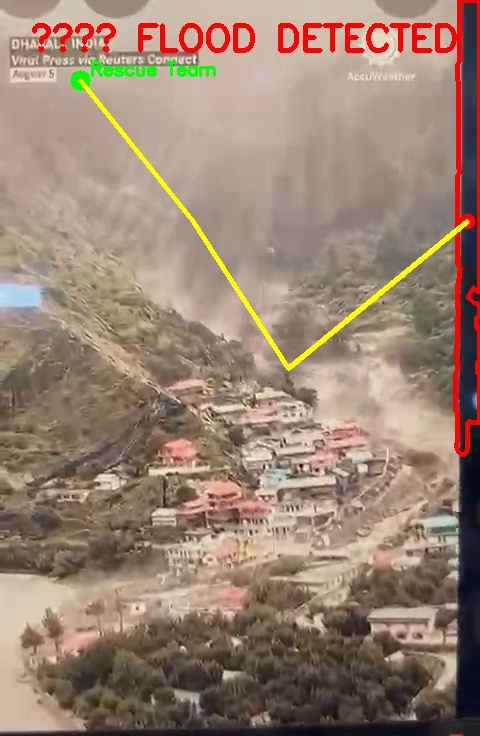

KeyboardInterrupt: 

In [ ]:
# ===============================
# FLOOD DASHBOARD WITH SIREN ALERT
# ===============================

from IPython.display import display, Image, Audio
import cv2
import numpy as np
import time

# -------------------------------
# SIREN SOUND FUNCTION
# -------------------------------
def play_siren():
    sample_rate = 44100
    duration = 1.5

    t = np.linspace(0, duration, int(sample_rate*duration))

    # emergency siren frequency sweep
    wave = np.sin(2*np.pi*(400 + 600*np.sin(2*np.pi*2*t))*t)

    return Audio(wave, rate=sample_rate, autoplay=True)


# -------------------------------
# LOAD VIDEO
# -------------------------------
video_path = list(uploaded.keys())[0]
cap = cv2.VideoCapture(video_path)

display_handle = display(None, display_id=True)

siren_played = False   # prevents repeated alarm


# ===============================
# MAIN LOOP
# ===============================
while True:
    ret, frame = cap.read()
    if not ret:
        break

    display_frame = frame.copy()
    h, w, _ = display_frame.shape

    # -----------------------------------
    # FLOOD DETECTION (COLOR SEGMENTATION)
    # -----------------------------------
    hsv = cv2.cvtColor(display_frame, cv2.COLOR_BGR2HSV)

    lower_blue = np.array([90,50,50])
    upper_blue = np.array([140,255,255])

    mask = cv2.inRange(hsv, lower_blue, upper_blue)
    mask = cv2.GaussianBlur(mask,(11,11),0)

    contours,_ = cv2.findContours(mask,
                                  cv2.RETR_EXTERNAL,
                                  cv2.CHAIN_APPROX_SIMPLE)

    flood_detected = False
    flood_center = None

    for cnt in contours:
        if cv2.contourArea(cnt) > 5000:

            flood_detected = True

            # draw flood boundary
            cv2.drawContours(display_frame,[cnt],-1,(0,0,255),3)

            # compute center
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cx = int(M["m10"]/M["m00"])
                cy = int(M["m01"]/M["m00"])
                flood_center = (cx,cy)

                cv2.circle(display_frame,flood_center,8,(0,0,255),-1)

    # -----------------------------------
    # RESCUE ROUTE ON VIDEO
    # -----------------------------------
    if flood_detected and flood_center:

        # 🔊 PLAY SIREN ONLY ONCE
        if not siren_played:
            display(play_siren())
            siren_played = True

        rescue_point = (80,80)

        # rescue marker
        cv2.circle(display_frame,rescue_point,10,(0,255,0),-1)
        cv2.putText(display_frame,"Rescue Team",
                    (90,75),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,(0,255,0),2)

        # route path
        route_pts = np.array([
            rescue_point,
            (int(w*0.4), int(h*0.3)),
            (int(w*0.6), int(h*0.5)),
            flood_center
        ])

        cv2.polylines(display_frame,
                      [route_pts],
                      False,
                      (0,255,255),
                      4)

        # destination label
        cv2.putText(display_frame,"Flood Zone",
                    (flood_center[0]+10,flood_center[1]),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,(0,0,255),2)

        # ALERT TEXT
        cv2.putText(display_frame,
                    "🚨 FLOOD DETECTED",
                    (30,50),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1.2,(0,0,255),4)

    else:
        siren_played = False

        cv2.putText(display_frame,
                    "AREA SAFE",
                    (30,50),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1.2,(0,255,0),3)

    # -----------------------------------
    # SMOOTH VIDEO DISPLAY (NO BLINK)
    # -----------------------------------
    _, img_encoded = cv2.imencode('.jpg', display_frame)
    display_handle.update(Image(data=img_encoded.tobytes()))

    time.sleep(0.03)

cap.release()

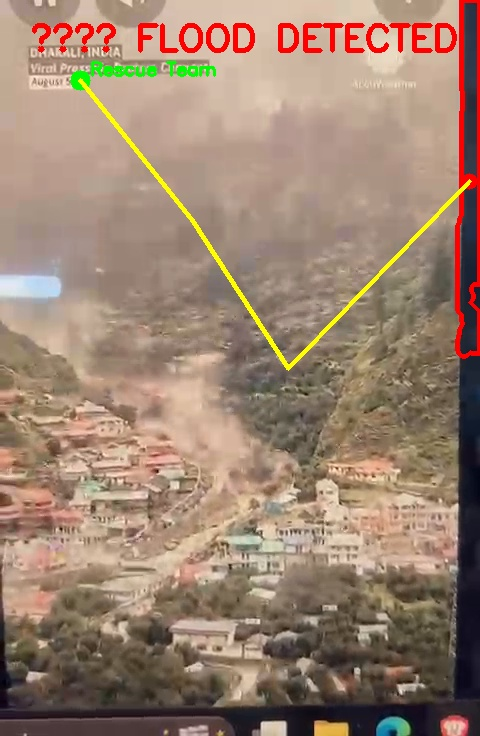

KeyboardInterrupt: 

In [ ]:
from IPython.display import display, Image, Audio
import cv2
import numpy as np
import time

# -------------------------------
# BETTER SIREN SOUND
# -------------------------------
def play_siren():
    sample_rate = 44100

    def tone(freq, duration):
        t = np.linspace(0, duration, int(sample_rate*duration), False)
        return np.sin(2*np.pi*freq*t)

    high = tone(1000, 0.35)
    low  = tone(500, 0.35)
    pause = np.zeros(int(sample_rate*0.15))

    siren_wave = np.concatenate([
        high, pause, low, pause,
        high, pause, low, pause,
        high, pause, low
    ])

    siren_wave *= 0.4  # softer volume

    return Audio(siren_wave, rate=sample_rate, autoplay=True)


# -------------------------------
# LOAD VIDEO
# -------------------------------
video_path = list(uploaded.keys())[0]
cap = cv2.VideoCapture(video_path)

display_handle = display(None, display_id=True)

siren_played = False


# -------------------------------
# MAIN LOOP
# -------------------------------
while True:
    ret, frame = cap.read()
    if not ret:
        break

    display_frame = frame.copy()
    h, w, _ = display_frame.shape

    # Flood detection (color-based demo)
    hsv = cv2.cvtColor(display_frame, cv2.COLOR_BGR2HSV)

    lower_blue = np.array([90,50,50])
    upper_blue = np.array([140,255,255])

    mask = cv2.inRange(hsv, lower_blue, upper_blue)
    mask = cv2.GaussianBlur(mask,(11,11),0)

    contours,_ = cv2.findContours(mask,
                                  cv2.RETR_EXTERNAL,
                                  cv2.CHAIN_APPROX_SIMPLE)

    flood_detected = False
    flood_center = None

    for cnt in contours:
        if cv2.contourArea(cnt) > 5000:

            flood_detected = True
            cv2.drawContours(display_frame,[cnt],-1,(0,0,255),3)

            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cx = int(M["m10"]/M["m00"])
                cy = int(M["m01"]/M["m00"])
                flood_center = (cx,cy)
                cv2.circle(display_frame,flood_center,8,(0,0,255),-1)

    # Rescue route + alert
    if flood_detected and flood_center:

        if not siren_played:
            display(play_siren())
            siren_played = True

        rescue_point = (80,80)

        cv2.circle(display_frame,rescue_point,10,(0,255,0),-1)
        cv2.putText(display_frame,"Rescue Team",
                    (90,75),
                    cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,0),2)

        route_pts = np.array([
            rescue_point,
            (int(w*0.4), int(h*0.3)),
            (int(w*0.6), int(h*0.5)),
            flood_center
        ])

        cv2.polylines(display_frame,[route_pts],False,(0,255,255),4)

        cv2.putText(display_frame,"Flood Zone",
                    (flood_center[0]+10,flood_center[1]),
                    cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,0,255),2)

        cv2.putText(display_frame,
                    "🚨 FLOOD DETECTED",
                    (30,50),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1.2,(0,0,255),4)

    else:
        siren_played = False
        cv2.putText(display_frame,"AREA SAFE",
                    (30,50),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1.2,(0,255,0),3)

    # Smooth display
    _, img_encoded = cv2.imencode('.jpg', display_frame)
    display_handle.update(Image(data=img_encoded.tobytes()))

    time.sleep(0.03)

cap.release()